In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.max_columns = None
pd.options.display.max_rows = None


### DATA DESCRIPTION

Data available at: [tennis_wta](https://github.com/JeffSackmann/tennis_wta).  

In [2]:
matches_cleaned = pd.read_csv("/Users/martapriv/Documents/PUM/inzynierka_code/Tennis_Scores_Predictions/data/01_raw/combined_matches.csv", index_col=0)

/var/folders/hd/nmlhh_n952v82g530l_c0x_00000gr/T/ipykernel_16789/3426877525.py:1: DtypeWarning: Columns (4,9,17) have mixed types. Specify dtype option on import or set low_memory=False.
  matches_cleaned = pd.read_csv("/Users/martapriv/Documents/PUM/inzynierka_code/Tennis_Scores_Predictions/data/01_raw/combined_matches.csv", index_col=0)


### INITIAL ANALYSIS

In [3]:
matches_cleaned.tail()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,loser_seed,loser_entry,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,score,best_of,round,minutes,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpSaved,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
158087,2024-W-FC-2024-POS,BJK Cup Playoffs,NaN,16,D,20241115,226,201709,NaN,NaN,Yulia Putintseva,R,163.0,KAZ,29.8,220454,NaN,NaN,Yeon Woo Ku,U,NaN,KOR,21.6,6-4 7-5,3,RR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.0,1844.0,418.0,141.0
158088,2024-W-FC-2024-POS,BJK Cup Playoffs,NaN,16,D,20241115,227,215785,NaN,NaN,Camila Osorio,R,162.0,COL,22.8,219875,NaN,NaN,Varvara Gracheva,R,NaN,FRA,24.2,6-2 7-5,3,RR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.0,989.0,66.0,949.0
158089,2024-W-FC-2024-POS,BJK Cup Playoffs,NaN,16,D,20241115,228,221257,NaN,NaN,Sinja Kraus,R,NaN,AUT,22.5,201615,NaN,NaN,Lesia Tsurenko,R,174.0,UKR,35.4,6-1 6-1,3,RR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,222.0,327.0,118.0,648.0
158090,2024-W-FC-2024-POS,BJK Cup Playoffs,NaN,16,D,20241115,229,216262,NaN,NaN,Clara Burel,R,176.0,FRA,23.6,215306,NaN,NaN,Emiliana Arango,R,NaN,COL,23.9,7-5 6-4,3,RR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.0,900.0,180.0,394.0
158091,2024-W-FC-2024-POS,BJK Cup Playoffs,NaN,16,D,20241115,230,215290,NaN,NaN,Katarina Zavatska,R,173.0,UKR,24.7,211814,NaN,NaN,Julia Grabher,R,170.0,AUT,28.3,6-2 7-5,3,RR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,229.0,315.0,523.0,93.0


### EXCLUDE DATA AVIALABLE AFTER END OF THE MATCH

In [4]:
columns_before_match = ['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level',
       'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry',
       'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age',
       'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand',
       'loser_ht', 'loser_ioc', 'loser_age', 'round',
       'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points']
matches_cleaned = matches_cleaned[columns_before_match]
matches_cleaned.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,loser_seed,loser_entry,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,round,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,1968-W-OL-MEX-01A-1968,Guadalajara Olympics Demo,Clay,13.0,O,19681014,1,200781,NaN,NaN,Edda Buding,R,NaN,FRG,31.9,200795,NaN,NaN,Patricia Montano,U,NaN,MEX,16.1,R16,NaN,NaN,NaN,NaN
1,1968-W-OL-MEX-01A-1968,Guadalajara Olympics Demo,Clay,13.0,O,19681014,2,202512,NaN,NaN,Lucia Gongora,U,NaN,MEX,21.9,200862,NaN,NaN,Valerie Ziegenfuss,R,173.0,USA,19.2,R16,NaN,NaN,NaN,NaN
2,1968-W-OL-MEX-01A-1968,Guadalajara Olympics Demo,Clay,13.0,O,19681014,3,200869,NaN,NaN,Maria Eugenia Guzman,U,NaN,ECU,23.0,200863,NaN,NaN,Zaiga Yansone,U,NaN,URS,17.7,R16,NaN,NaN,NaN,NaN
3,1968-W-OL-MEX-01A-1968,Guadalajara Olympics Demo,Clay,13.0,O,19681014,4,200274,NaN,NaN,Julie Heldman,R,170.0,USA,22.8,200834,NaN,NaN,Suzana Gesteira,U,NaN,BRA,21.0,R16,NaN,NaN,NaN,NaN
4,1968-W-OL-MEX-01A-1968,Guadalajara Olympics Demo,Clay,13.0,O,19681014,5,200791,NaN,NaN,Rosie Reyes,R,NaN,FRA,29.5,202513,NaN,NaN,Ana Maria Ycaza,U,NaN,ECU,17.4,R16,NaN,NaN,NaN,NaN


### INCLUDE DATA OF ACTIVE PLAYERS

Include data only about players who were active in the last 6 years (from 2020 forward)

In [5]:
def filter_active_players(df: pd.DataFrame) -> pd.DataFrame:
    """
    Filters the dataframe, keeping only matches involving active players
    (that is, players who have competed in the last 4 years).

    Parameters:
    df (pd.DataFrame): dataframe containing columns
        'tourney_date', 'winner_name', 'loser_name'

    Returns:
    pd.DataFrame: przefiltrowany dataframe
    """

    print(f"all dataframe size: {df.shape[0]}")

    # select the last 4 years (>= 2020)
    last_years_df = df[df["tourney_date"] >= 20200000]
    print(f"records from last four years: {last_years_df.shape[0]}")

    # set of active players
    active_players = set(np.concatenate([
        last_years_df["winner_name"].values,
        last_years_df["loser_name"].values
    ]))

    print(f"active players from the last four years: {len(active_players)}")

    # filter the data
    df = df[
        df["winner_name"].isin(active_players) |
        df["loser_name"].isin(active_players)
    ]

    print(f"data narrowed to only active players: {df.shape[0]}")

    return df

matches_cleaned = filter_active_players(matches_cleaned)

all dataframe size: 158092
records from last four years: 11966
active players from the last four years: 714
data narrowed to only active players: 41576


### DATA QUALITY

In [6]:
matches_cleaned.replace('nan', np.nan, inplace=True)

In [7]:
# Percentages of missing values
missing_percent = (matches_cleaned.isna().sum() / len(matches_cleaned) * 100).reset_index()
missing_number = (matches_cleaned.isna().sum()).reset_index()

missing_percent.columns = ['column', 'percent_missing']
missing_number.columns = ['column', 'number_missing']

# Add the number of missing values to the percentage table
missing_percent['number_missing'] = missing_number['number_missing']
missing_percent = missing_percent.sort_values(by='percent_missing', ascending=False)
missing_percent

,column,percent_missing,number_missing
9,winner_entry,86.482586,35956
17,loser_entry,78.802675,32763
16,loser_seed,74.672888,31046
8,winner_seed,55.782182,23192
20,loser_ht,9.887916,4111
12,winner_ht,6.167019,2564
27,loser_rank_points,1.743794,725
26,loser_rank,1.743794,725
25,winner_rank_points,0.764864,318
24,winner_rank,0.764864,318


##### winner_entry / loser_entry 

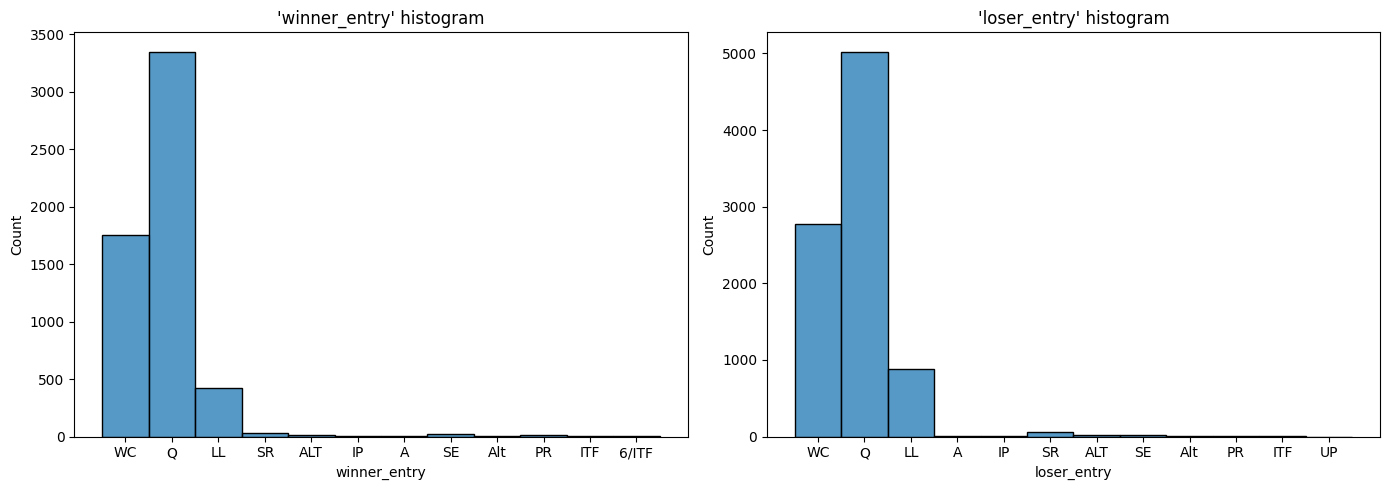

In [8]:
# Subplot for 'winner_entry' and 'loser_entry'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(matches_cleaned['winner_entry'], ax=axes[0], kde=False)
axes[0].set_title("'winner_entry' histogram")
axes[0].set_xlabel('winner_entry')
axes[0].set_ylabel('Count')

sns.histplot(matches_cleaned['loser_entry'], ax=axes[1], kde=False)
axes[1].set_title("'loser_entry' histogram")
axes[1].set_xlabel('loser_entry')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Based on the overall tennis knowledge, I would fill empyt values with the category which indicates that players were into tournament based on their normal ranking.

In [9]:
# filling Nan values
matches_cleaned['winner_entry'] = matches_cleaned['winner_entry'].fillna('R')
matches_cleaned['loser_entry'] = matches_cleaned['loser_entry'].fillna('R')

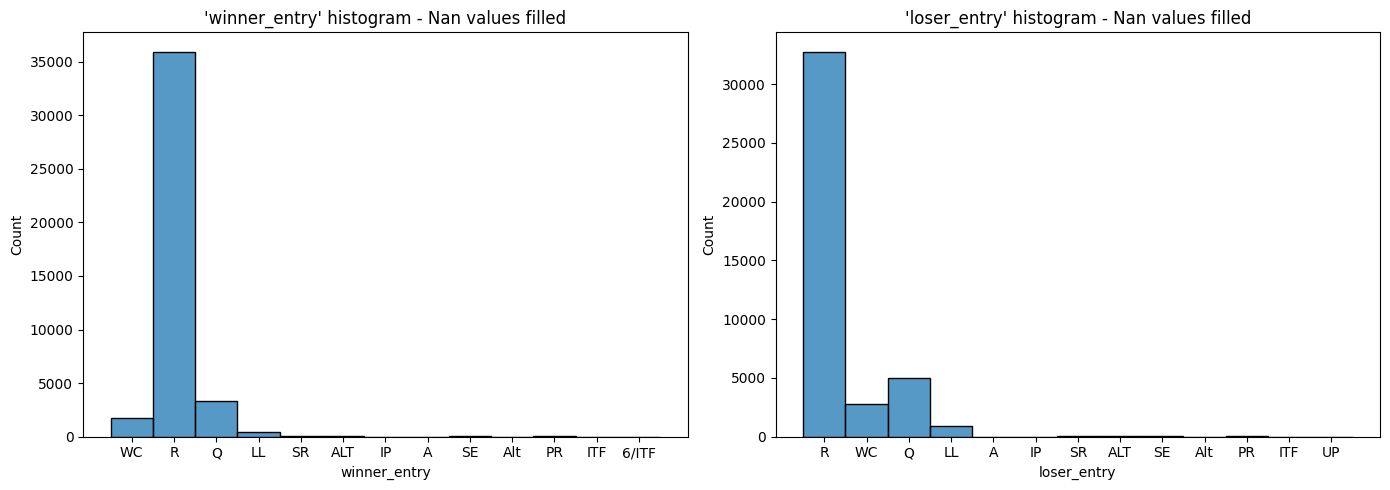

In [10]:
# Subplot after filling nan values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(matches_cleaned['winner_entry'], ax=axes[0], kde=False, stat='count', discrete=True)
axes[0].set_title("'winner_entry' histogram - Nan values filled")
axes[0].set_xlabel('winner_entry')
axes[0].set_ylabel('Count')

sns.histplot(matches_cleaned['loser_entry'], ax=axes[1], kde=False)
axes[1].set_title("'loser_entry' histogram - Nan values filled")
axes[1].set_xlabel('loser_entry')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

##### winner_seed / loser_seed

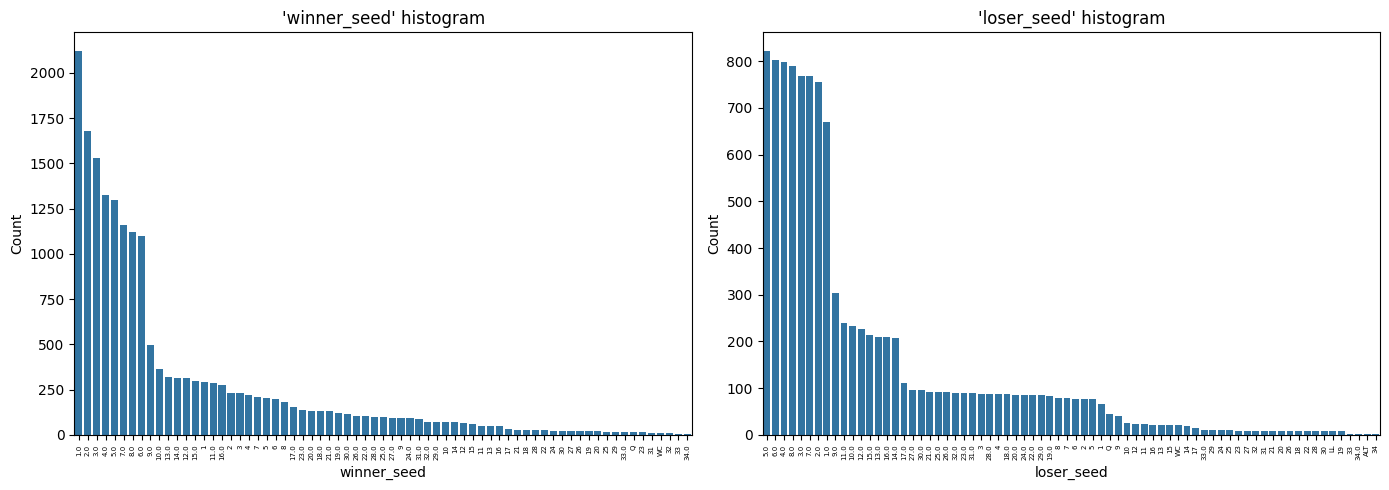

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# winner_seed
winner_seed_order = matches_cleaned['winner_seed'].dropna().astype(str).value_counts().index
sns.countplot(
    x=matches_cleaned['winner_seed'].dropna().astype(str),
    ax=axes[0],
    order=winner_seed_order
)
axes[0].set_title("'winner_seed' histogram")
axes[0].set_xlabel('winner_seed')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90, labelsize=5)

# loser_seed
loser_seed_order = matches_cleaned['loser_seed'].dropna().astype(str).value_counts().index
sns.countplot(
    x=matches_cleaned['loser_seed'].dropna().astype(str),
    ax=axes[1],
    order=loser_seed_order
)
axes[1].set_title("'loser_seed' histogram")
axes[1].set_xlabel('loser_seed')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=90, labelsize=5)

plt.tight_layout()
plt.show()

Those columns are mostly Nan and are not very important features, so they will be dropped

In [12]:
matches_cleaned = matches_cleaned.drop(columns=['winner_seed', 'loser_seed'])

##### winner_ht / loser_ht

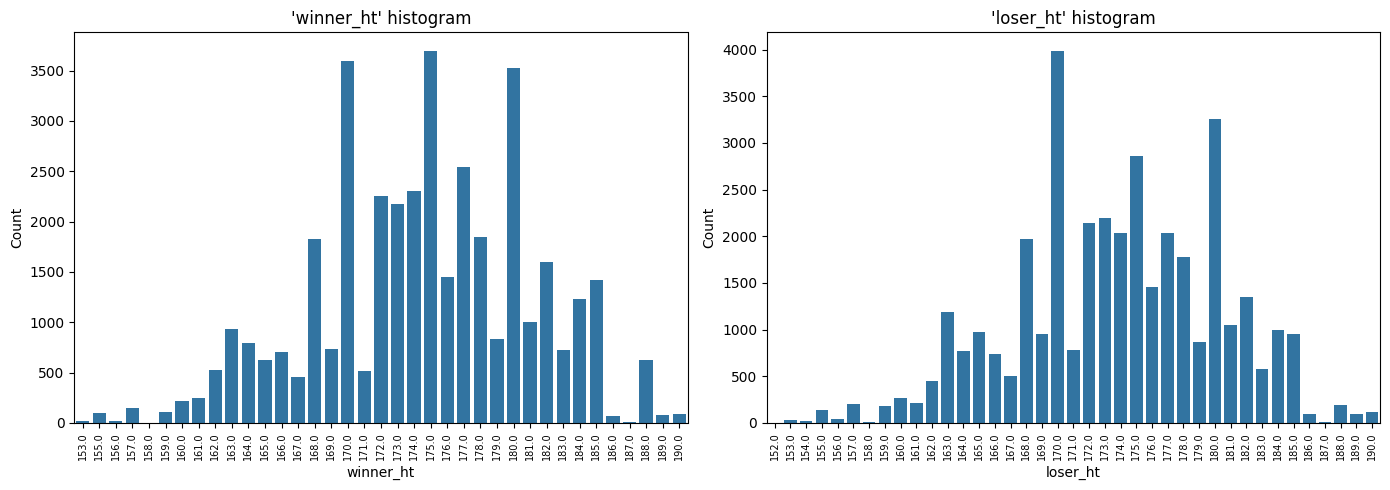

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# winner_ht
sns.countplot(
    x=matches_cleaned['winner_ht'].dropna(),
    ax=axes[0],
)
axes[0].set_title("'winner_ht' histogram")
axes[0].set_xlabel('winner_ht')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)

# loser_ht
sns.countplot(
    x=matches_cleaned['loser_ht'].dropna(),
    ax=axes[1],
)
axes[1].set_title("'loser_ht' histogram")
axes[1].set_xlabel('loser_ht')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)

plt.tight_layout()
plt.show()

Missing values will be replaced with the average values

In [14]:
# fill nan with avg (rounded to integer)
matches_cleaned['winner_ht'] = matches_cleaned['winner_ht'].fillna(round(matches_cleaned['winner_ht'].mean())).astype(int)
matches_cleaned['loser_ht'] = matches_cleaned['loser_ht'].fillna(round(matches_cleaned['loser_ht'].mean())).astype(int)

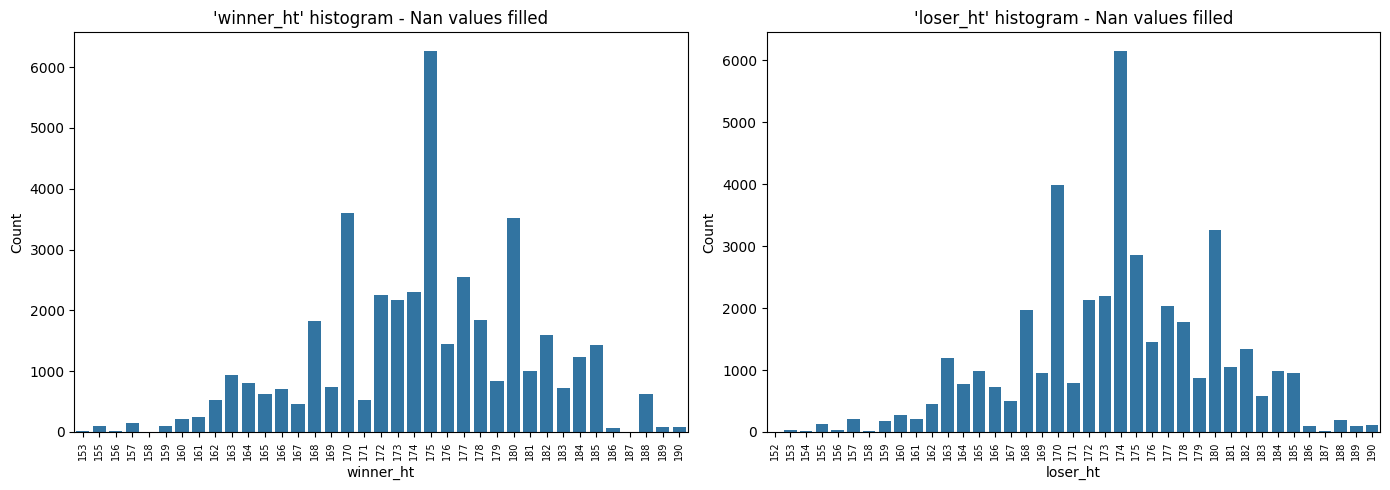

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# winner_ht
sns.countplot(
    x=matches_cleaned['winner_ht'].dropna(),
    ax=axes[0],
)
axes[0].set_title("'winner_ht' histogram - Nan values filled")
axes[0].set_xlabel('winner_ht')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)

# loser_ht
sns.countplot(
    x=matches_cleaned['loser_ht'].dropna(),
    ax=axes[1],
)
axes[1].set_title("'loser_ht' histogram - Nan values filled")
axes[1].set_xlabel('loser_ht')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)

plt.tight_layout()
plt.show()

##### winner_rank_points / loser_rank_points

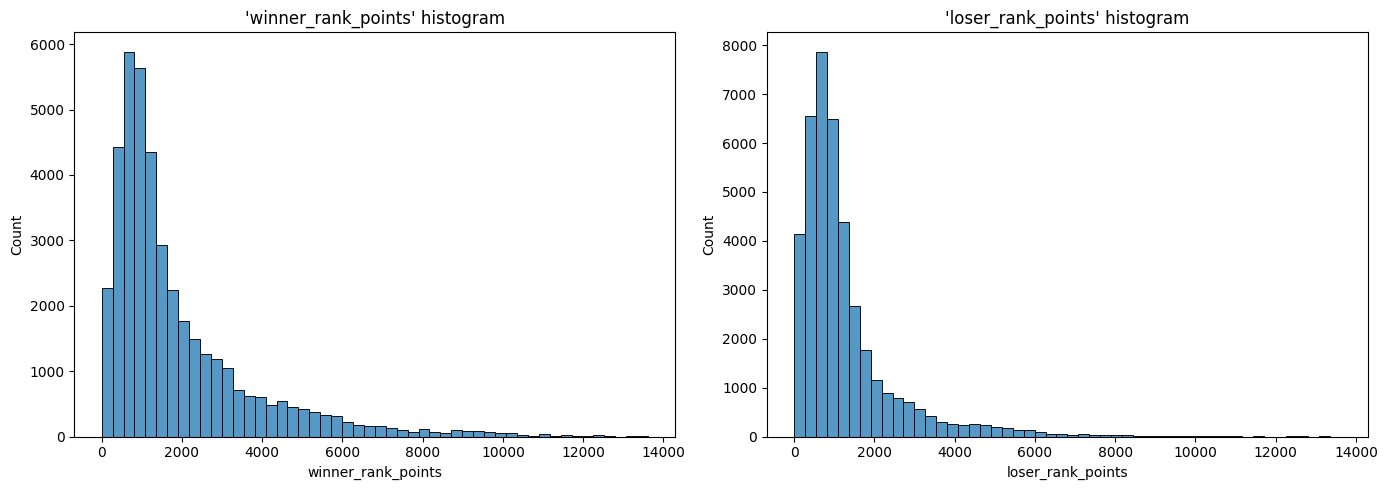

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# winner_rank_points
sns.histplot(
    matches_cleaned['winner_rank_points'].dropna(),
    ax=axes[0],
    bins=50
)
axes[0].set_title("'winner_rank_points' histogram")
axes[0].set_xlabel('winner_rank_points')
axes[0].set_ylabel('Count')

# loser_rank_points
sns.histplot(
    matches_cleaned['loser_rank_points'].dropna(),
    ax=axes[1],
    bins=50
)
axes[1].set_title("'loser_rank_points' histogram")
axes[1].set_xlabel('loser_rank_points')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Null records are less than 5% of the whole datasaet so they will be dropped.

In [17]:
# drop Nan records for 'winner_rank_points' and 'loser_rank_points'
matches_cleaned = matches_cleaned.dropna(subset=['winner_rank_points', 'loser_rank_points'])

##### winner_rank / loser_rank

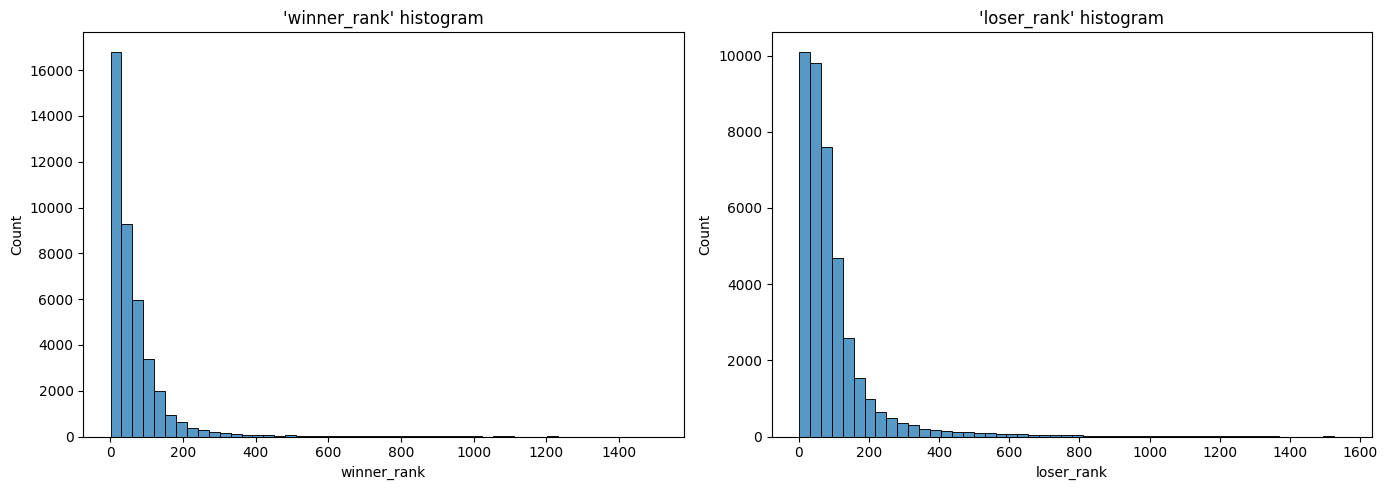

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# winner_rank
sns.histplot(
    matches_cleaned['winner_rank'].dropna(),
    ax=axes[0],
    bins=50
)
axes[0].set_title("'winner_rank' histogram")
axes[0].set_xlabel('winner_rank')
axes[0].set_ylabel('Count')

# loser_rank
sns.histplot(
    matches_cleaned['loser_rank'].dropna(),
    ax=axes[1],
    bins=50
)
axes[1].set_title("'loser_rank' histogram")
axes[1].set_xlabel('loser_rank')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Null records are less than 5% of the whole datasaet so they will be dropped.

In [19]:
# drop Nan records for 'winner_rank' and 'loser_rank'
matches_cleaned = matches_cleaned.dropna(subset=['winner_rank', 'loser_rank'])

##### Other columns with Nan values

Other columns with Nan values are: surface, loser_age, winner_age and loser_hand.  
Since they number of missing rows is less than 5% of the whole dataset, those records will be dropped.  

In [20]:
# drop Nan records for 'surface', 'loser_age', 'winner_age', 'loser_hand'
matches_cleaned = matches_cleaned.dropna(subset=['surface', 'loser_age', 'winner_age', 'loser_hand'])

In [22]:
print(f"brak pustych wartosci:\n{matches_cleaned.isna().sum()}")
print(f"finalne podsumowanie: {matches_cleaned.shape}")

brak pustych wartosci:
tourney_id            0
tourney_name          0
surface               0
draw_size             0
tourney_level         0
tourney_date          0
match_num             0
winner_id             0
winner_entry          0
winner_name           0
winner_hand           0
winner_ht             0
winner_ioc            0
winner_age            0
loser_id              0
loser_entry           0
loser_name            0
loser_hand            0
loser_ht              0
loser_ioc             0
loser_age             0
round                 0
winner_rank           0
winner_rank_points    0
loser_rank            0
loser_rank_points     0
dtype: int64
finalne podsumowanie: (40682, 26)


### EDA - EXPLORATORY DATA ANALYSIS

In [23]:
numeric_cols = []
cat_cols = []
for i in matches_cleaned.columns:
    if matches_cleaned[i].dtype == "int64" or matches_cleaned[i].dtype == "float64":
        numeric_cols.append(i)
    else:
        cat_cols.append(i)
print(f"numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"categorical columns ({len(cat_cols)}): {cat_cols}")

numeric columns (12): ['tourney_date', 'match_num', 'winner_id', 'winner_ht', 'winner_age', 'loser_id', 'loser_ht', 'loser_age', 'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points']
categorical columns (14): ['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level', 'winner_entry', 'winner_name', 'winner_hand', 'winner_ioc', 'loser_entry', 'loser_name', 'loser_hand', 'loser_ioc', 'round']


##### Numeric columns statistics

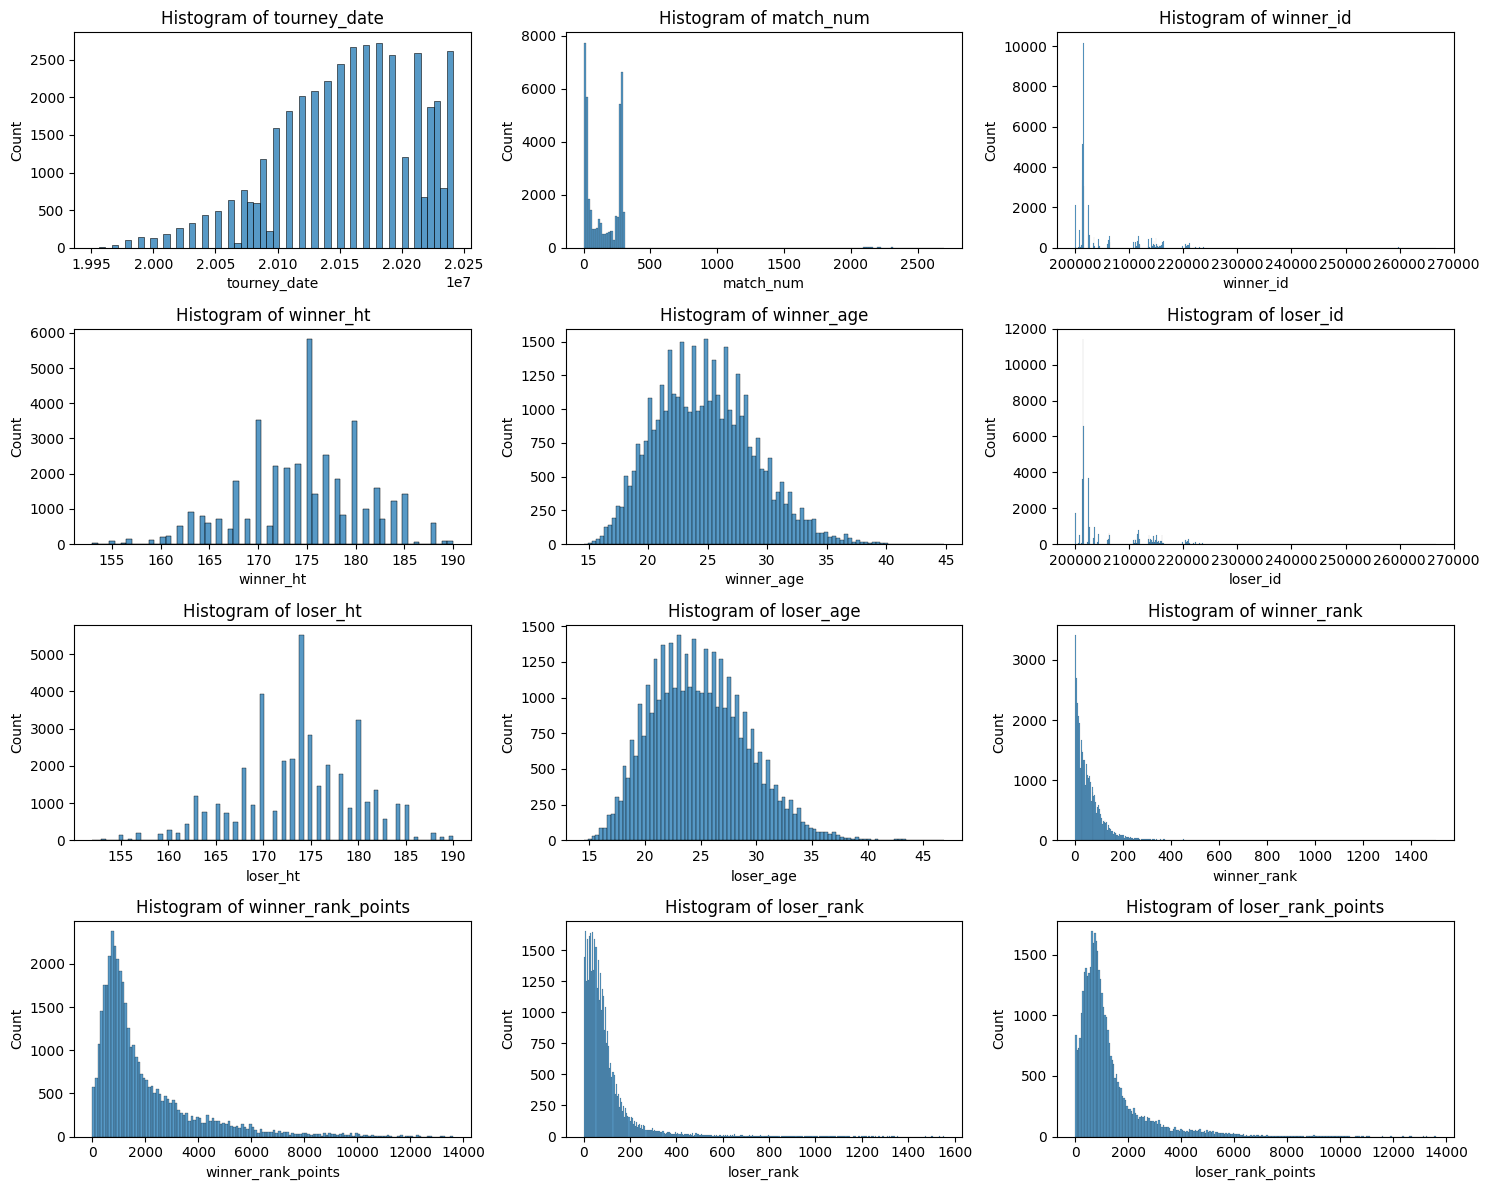

In [24]:
# numeric cols histograms
import math
num_plots = len(numeric_cols)
rows, cols = 4, 3
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(matches_cleaned[col].dropna(), ax=axes[i])
    axes[i].set_title(f"Histogram of {col}")


plt.tight_layout()
plt.show()

In [25]:
# drop identyfying columns: match_num, winner_id, loser_id
matches_cleaned.drop(columns=['match_num', 'winner_id', 'loser_id'], inplace=True)

##### Categorical columns statistics

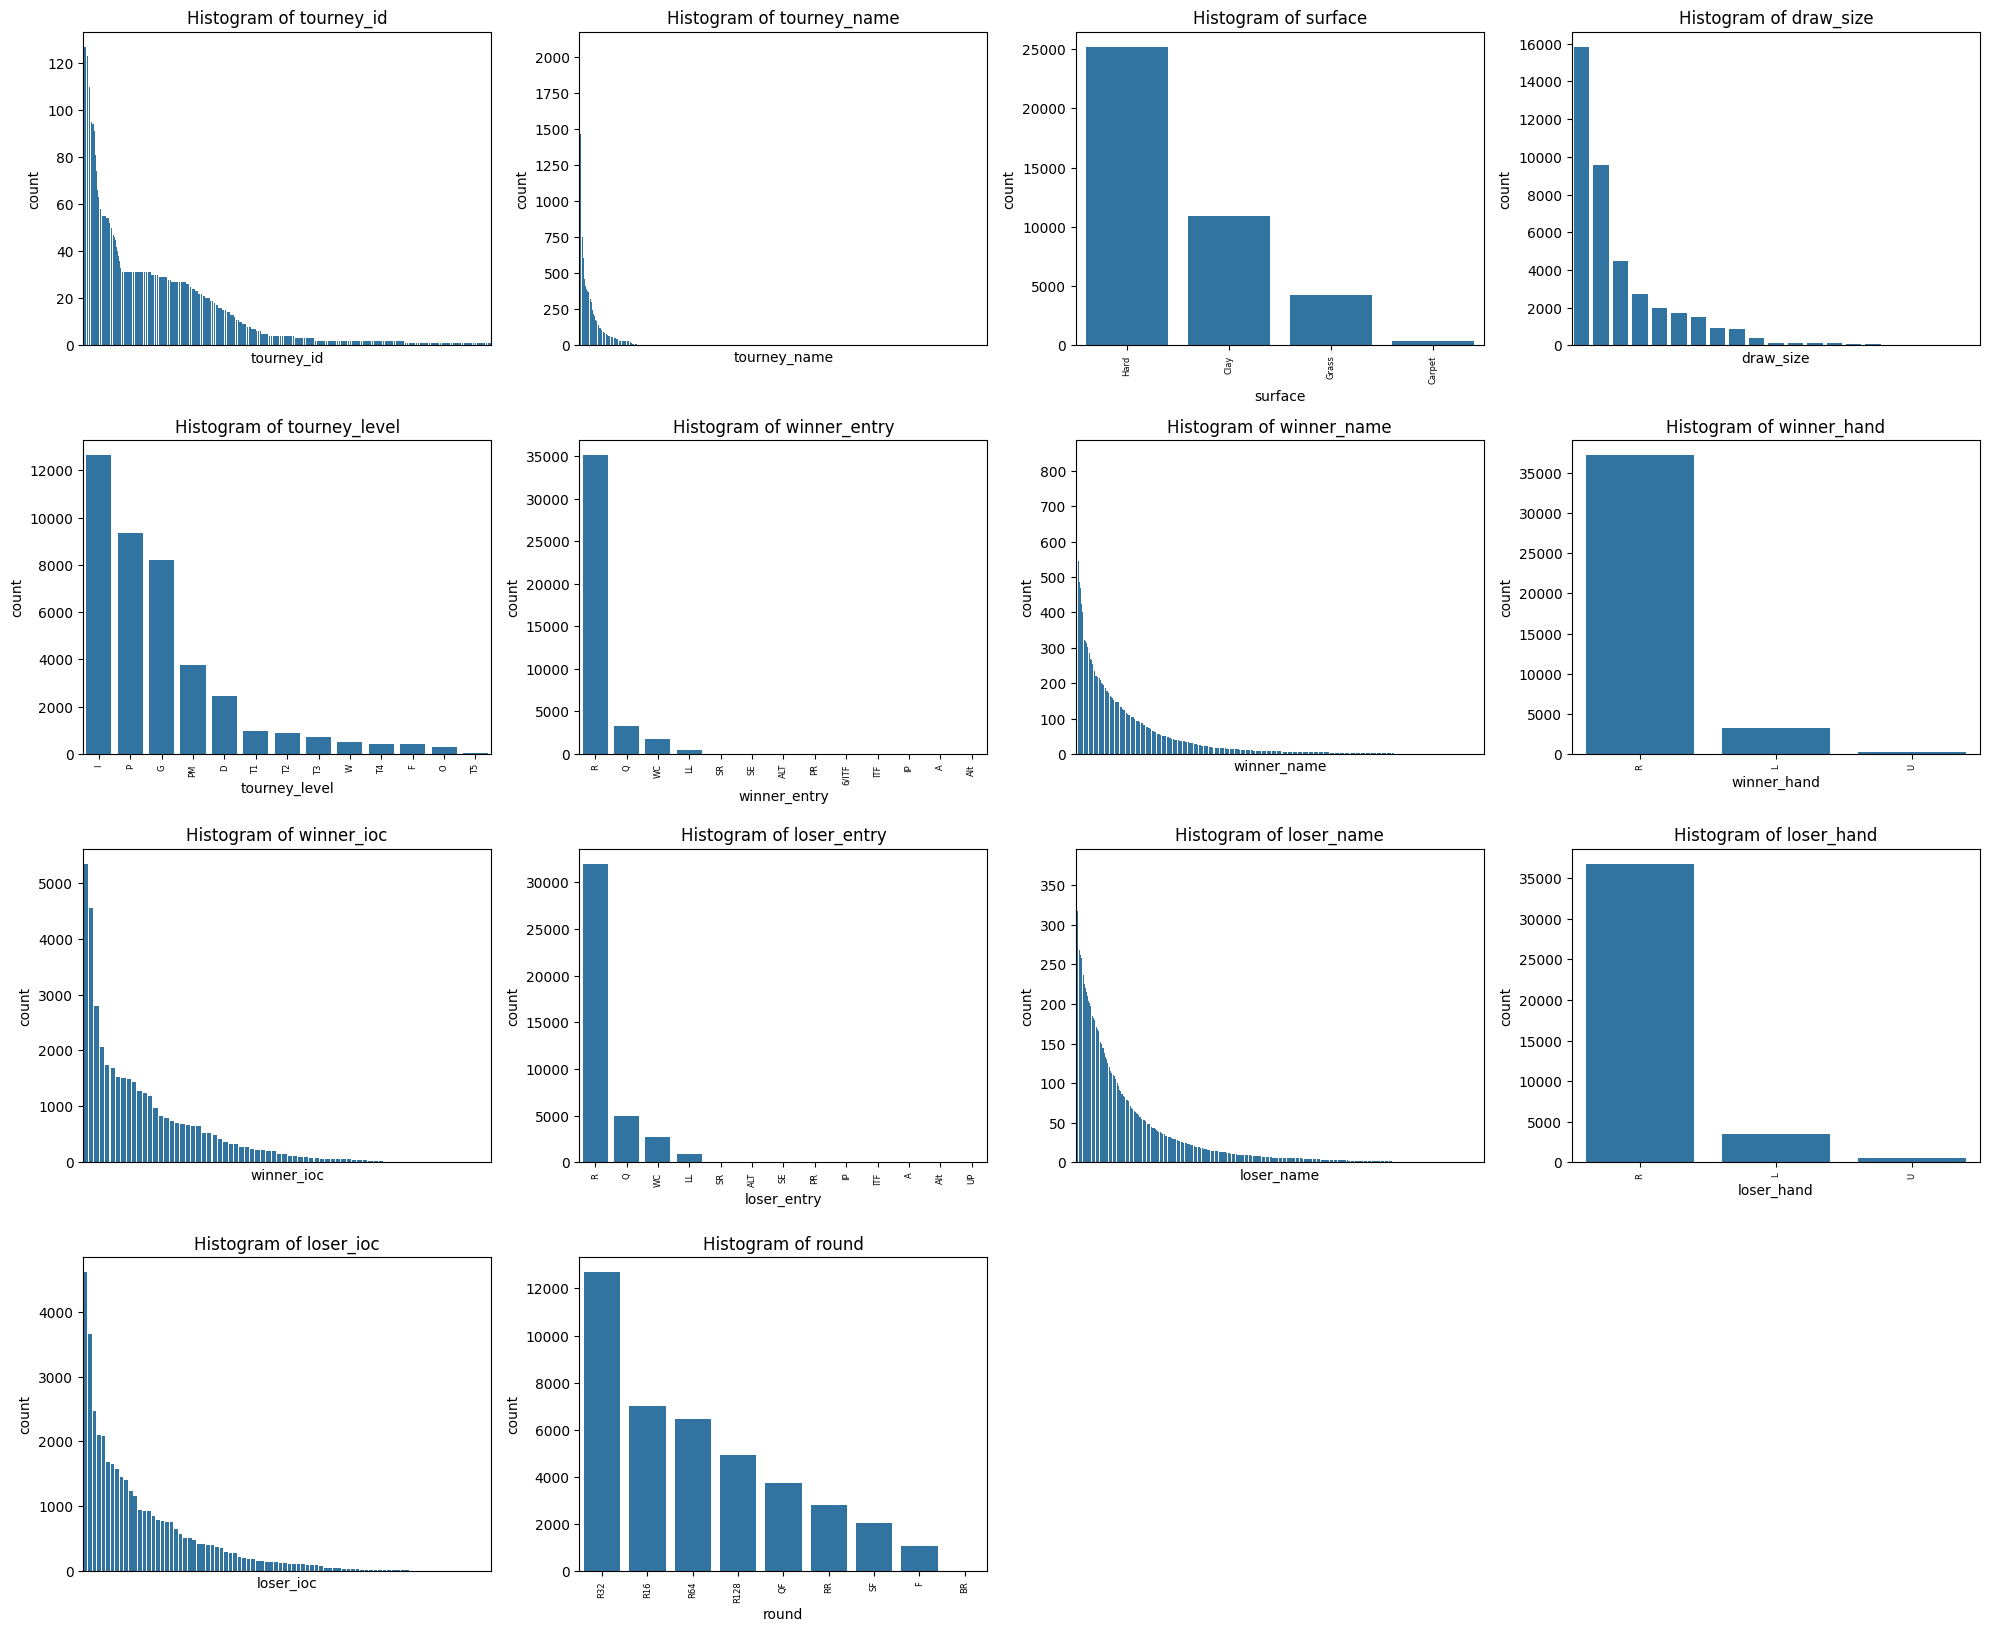

In [26]:
import math
num_plots = len(cat_cols)
rows, cols = 5, 4
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    unique_vals = matches_cleaned[col].nunique()
    sns.countplot(x=matches_cleaned[col].dropna(), ax=axes[i], order=matches_cleaned[col].value_counts().index)
    axes[i].set_title(f"Histogram of {col}")
    if unique_vals > 20:
        axes[i].set_xticks([])  # remove x-axis labels
    else:
        axes[i].tick_params(axis='x', labelsize=6, rotation=90)

# Hide empty plots if there are fewer than 15 charts
for j in range(num_plots, rows*cols):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [239]:
# look into different tourney levels
levels = active_df['tourney_level'].unique()

for i in levels:
    tt = active_df.copy()
    tt = tt[tt['tourney_level'] == i]
    print(f"for tourney level: {i}")
    print(f"min date: {min(tt['tourney_date'])}, max date: {max(tt['tourney_date'])}")

for tourney level: W
min date: 19941031, max date: 20241125
for tourney level: G
min date: 19970526, max date: 20240826
for tourney level: D
min date: 19990724, max date: 20241115
for tourney level: O
min date: 20000919, max date: 20240729
for tourney level: T1
min date: 20000310, max date: 20081006
for tourney level: T2
min date: 20000207, max date: 20081020
for tourney level: T3
min date: 20000619, max date: 20081027
for tourney level: T4
min date: 20000109, max date: 20080929
for tourney level: F
min date: 20001113, max date: 20241104
for tourney level: CC
min date: 20010305, max date: 20020304
for tourney level: T5
min date: 20011105, max date: 20050110
for tourney level: I
min date: 20090105, max date: 20241028
for tourney level: PM
min date: 20090309, max date: 20241007
for tourney level: P
min date: 20090112, max date: 20241021


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, '28'),
  Text(1, 0, '56'),
  Text(2, 0, '48'),
  Text(3, 0, '128'),
  Text(4, 0, '25'),
  Text(5, 0, '96'),
  Text(6, 0, '30'),
  Text(7, 0, '8'),
  Text(8, 0, '32'),
  Text(9, 0, '16'),
  Text(10, 0, '4'),
  Text(11, 0, '64'),
  Text(12, 0, '80'),
  Text(13, 0, '15'),
  Text(14, 0, '60'),
  Text(15, 0, '55'),
  Text(16, 0, '31'),
  Text(17, 0, '54'),
  Text(18, 0, '12'),
  Text(19, 0, '2'),
  Text(20, 0, '18')])

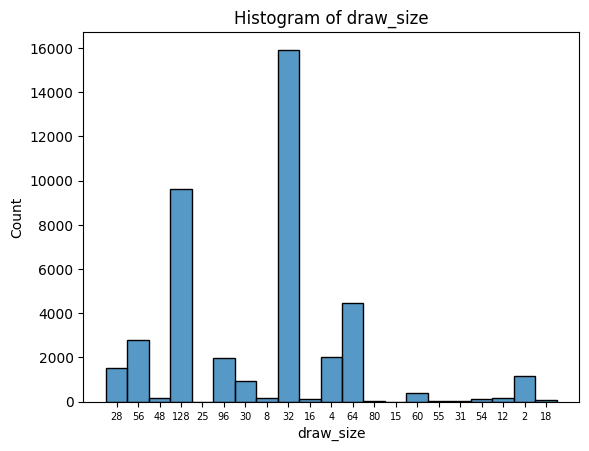

In [240]:
ax = sns.histplot(
    active_df,
    x=active_df["draw_size"].astype(str),
)
ax.set_title("Histogram of draw_size")
plt.xticks(size=7)

According to the dataset description, the [draw_size] column represents the number of players participating in the tournament.  
However, tournament draws are typically structured around powers of two, for example 16, 32, 64, and so on.  
Therefore, I round the values so they fall into the following buckets: 4, 8, 16, 32, 64, 128.  

In [241]:
active_df['draw_size'] = pd.cut(
    active_df['draw_size'],
    bins=[0, 4, 8, 16, 32, 64, 128],
    labels=[4, 8, 16, 32, 64, 128],
    include_lowest=True
).astype(str)

Text(0.5, 1.0, 'Histogram of draw_size')

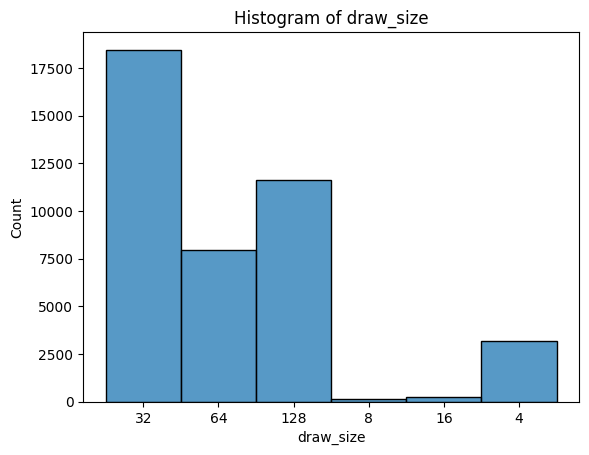

In [242]:
ax = sns.histplot(
    active_df,
    x=active_df["draw_size"].astype(str),
)
ax.set_title("Histogram of draw_size")

Text(0.5, 1.0, 'Histogram of round')

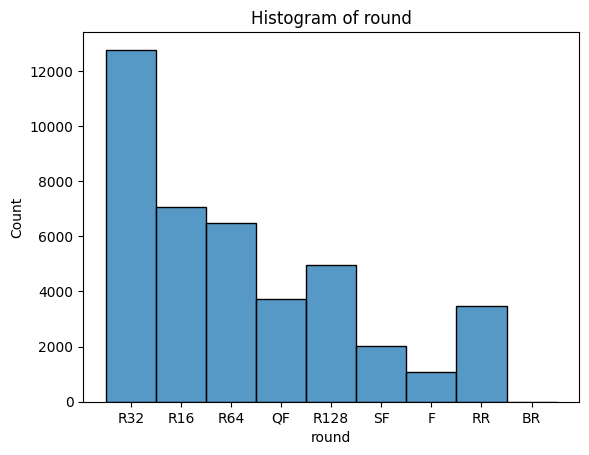

In [243]:
ax = sns.histplot(
    active_df,
    x="round",
)
ax.set_title("Histogram of round")

'BR' stands for the Olympic bronze medal match. To avoid adding noise, I map it to 'SF' (semifinal).

In [244]:
print(f"matches on 'BR' round: {active_df[active_df['round'] == 'BR']}")
active_df.loc[active_df['round'] == 'BR', 'round'] = 'SF'

matches on 'BR' round:                     tourney_id    tourney_name surface draw_size  \
113131  2008-W-OL-CHN-01A-2008        Olympics    Hard        64   
125222  2012-W-OL-GBR-01A-2012        Olympics   Grass        64   
137458                2016-O16        Olympics    Hard        64   
149153                2021-650  Tokyo Olympics    Hard        64   
157169               2024-0096  Paris Olympics    Clay        64   

       tourney_level  tourney_date  match_num  winner_id winner_seed  \
113131             O      20080811         64     201329         9.0   
125222             O      20120730         64     201458         1.0   
137458             O      20160808        163     201520          11   
149153             O      20210724        237     202494         4.0   
157169             O      20240729        168     216347         1.0   

       winner_entry        winner_name winner_hand  winner_ht winner_ioc  \
113131          NaN     Vera Zvonareva           R      172

Zamienie rundy aby abyly w formacie: R1, R2, R3, R4 zamiast R128, R64 itp.  
Logika:  

128 -> 64 -> 32 -> 16 -> QF -> SF -> F  
R1  -> R2  -> R3 -> R4 -> QF -> SF -> F  
  
64 -> 32 -> 16 -> QF -> SF -> F  
R1 -> R2 -> R3 -> QF -> SF -> F  

32 -> 16 -> QF -> SF -> F  
R1 -> R2 -> QF -> SF -> F  

16 -> QF -> SF -> F  
R1 -> QF -> SF -> F  

In [245]:
import math
print(f"unique round names: {active_df['round'].unique()}")
active_df['round'] = active_df.apply(
    lambda x: 
    f"R{int(math.log(int(x['draw_size']),2)) - int(math.log(int(x['round'].replace('R','')),2)) + 1}"
    if x['round'].count('R') == 1 
    else x['round'],
    axis=1
)

print(f"unique round names after changes: {active_df['round'].unique()}")

unique round names: ['R32' 'R16' 'R64' 'QF' 'R128' 'SF' 'F' 'RR']
unique round names after changes: ['R1' 'R2' 'QF' 'R3' 'R4' 'SF' 'F' 'RR']


Nie kazdy turniej ma tyle samo meczy.  
Przyklad:  
for Grand Slams, the draw includes 128 players, so the match order looks like this:  
R1 -> R2 -> R3 -> R4 -> QF -> SF -> F  

for smaller tournaments, however, the draw is typically 32 players, so the match order looks like this:  
R1 -> R2 -> QF -> SF -> F  

Therefore, I add a column that captures the order in which matches were played within a tournament.  

In [246]:
# add year for group by
active_df['year'] = active_df['tourney_date'].astype(str).str[:4]
round_order = {
    'R1': 1, 'R2': 2, 'R3': 3, 'R4': 4,
    'QF': 5, 'SF': 6, 'F': 7, 'RR':10
}
# add column with mapping
active_df['round_order'] = active_df['round'].map(round_order)
active_df = active_df.sort_values(['tourney_name', 'year', 'round_order'])

# add column with index
active_df['index_round'] = active_df.groupby(['tourney_name','year'])['round_order'].rank(method='dense').astype(int)
active_df[['round', 'round_order', 'index_round']].head(50)
active_df = active_df.drop(columns=['year', 'round_order'])
active_df.head(10)

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,loser_seed,loser_entry,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,round,winner_rank,winner_rank_points,loser_rank,loser_rank_points,index_round
119305,2010-W-INT-NED-01A-2010,'s Hertogenbosch,Grass,32,I,20100614,1,200003,1.0,WC,Justine Henin,R,167.0,BEL,28.0,201493,NaN,NaN,Angelique Kerber,L,173.0,GER,22.4,R1,18.0,2855.0,55.0,1148.0,1
119306,2010-W-INT-NED-01A-2010,'s Hertogenbosch,Grass,32,I,20100614,2,201311,NaN,NaN,Roberta Vinci,R,163.0,ITA,27.3,201366,NaN,NaN,Barbora Strycova,R,164.0,CZE,24.2,R1,51.0,1190.0,67.0,983.0,1
119308,2010-W-INT-NED-01A-2010,'s Hertogenbosch,Grass,32,I,20100614,4,201446,NaN,NaN,Sybille Bammer,L,174.0,AUT,30.1,201506,6.0,NaN,Sara Errani,R,164.0,ITA,23.1,R1,49.0,1240.0,33.0,1660.0,1
119309,2010-W-INT-NED-01A-2010,'s Hertogenbosch,Grass,32,I,20100614,5,201468,4.0,NaN,Yaroslava Shvedova,R,180.0,KAZ,22.7,201367,NaN,Q,Arantxa Parra Santonja,R,176.0,ESP,27.5,R1,31.0,1830.0,50.0,1218.0,1
119312,2010-W-INT-NED-01A-2010,'s Hertogenbosch,Grass,32,I,20100614,8,201567,5.0,NaN,Alexandra Dulgheru,R,172.0,ROU,21.0,201526,NaN,Q,Julie Coin,R,172.0,FRA,27.5,R1,32.0,1785.0,98.0,664.0,1
119313,2010-W-INT-NED-01A-2010,'s Hertogenbosch,Grass,32,I,20100614,9,201551,NaN,WC,Arantxa Rus,L,180.0,NED,19.5,201286,8.0,NaN,Anabel Medina Garrigues,R,169.0,ESP,27.8,R1,124.0,512.0,37.0,1455.0,1
119315,2010-W-INT-NED-01A-2010,'s Hertogenbosch,Grass,32,I,20100614,11,201465,NaN,NaN,Kirsten Flipkens,R,165.0,BEL,24.4,201447,NaN,NaN,Vania King,R,165.0,USA,21.2,R1,68.0,969.0,71.0,940.0,1
119317,2010-W-INT-NED-01A-2010,'s Hertogenbosch,Grass,32,I,20100614,13,201492,7.0,NaN,Andrea Petkovic,R,180.0,GER,22.7,201520,NaN,NaN,Petra Kvitova,L,183.0,CZE,20.2,R1,36.0,1486.0,61.0,1080.0,1
119319,2010-W-INT-NED-01A-2010,'s Hertogenbosch,Grass,32,I,20100614,15,201484,NaN,Q,Sandra Zahlavova,U,NaN,CZE,24.6,201455,NaN,NaN,Elena Vesnina,R,176.0,RUS,23.8,R1,88.0,735.0,41.0,1350.0,1
119323,2010-W-INT-NED-01A-2010,'s Hertogenbosch,Grass,32,I,20100614,19,201468,4.0,NaN,Yaroslava Shvedova,R,180.0,KAZ,22.7,201370,NaN,Q,Anastasia Rodionova,R,167.0,AUS,28.0,R2,31.0,1830.0,76.0,843.0,2


### VARIABLES CORRELATION

In [247]:
active_df.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,loser_seed,loser_entry,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,round,winner_rank,winner_rank_points,loser_rank,loser_rank_points,index_round
119305,2010-W-INT-NED-01A-2010,'s Hertogenbosch,Grass,32,I,20100614,1,200003,1.0,WC,Justine Henin,R,167.0,BEL,28.0,201493,NaN,NaN,Angelique Kerber,L,173.0,GER,22.4,R1,18.0,2855.0,55.0,1148.0,1
119306,2010-W-INT-NED-01A-2010,'s Hertogenbosch,Grass,32,I,20100614,2,201311,NaN,NaN,Roberta Vinci,R,163.0,ITA,27.3,201366,NaN,NaN,Barbora Strycova,R,164.0,CZE,24.2,R1,51.0,1190.0,67.0,983.0,1
119308,2010-W-INT-NED-01A-2010,'s Hertogenbosch,Grass,32,I,20100614,4,201446,NaN,NaN,Sybille Bammer,L,174.0,AUT,30.1,201506,6.0,NaN,Sara Errani,R,164.0,ITA,23.1,R1,49.0,1240.0,33.0,1660.0,1
119309,2010-W-INT-NED-01A-2010,'s Hertogenbosch,Grass,32,I,20100614,5,201468,4.0,NaN,Yaroslava Shvedova,R,180.0,KAZ,22.7,201367,NaN,Q,Arantxa Parra Santonja,R,176.0,ESP,27.5,R1,31.0,1830.0,50.0,1218.0,1
119312,2010-W-INT-NED-01A-2010,'s Hertogenbosch,Grass,32,I,20100614,8,201567,5.0,NaN,Alexandra Dulgheru,R,172.0,ROU,21.0,201526,NaN,Q,Julie Coin,R,172.0,FRA,27.5,R1,32.0,1785.0,98.0,664.0,1


<Axes: xlabel='surface', ylabel='Count'>

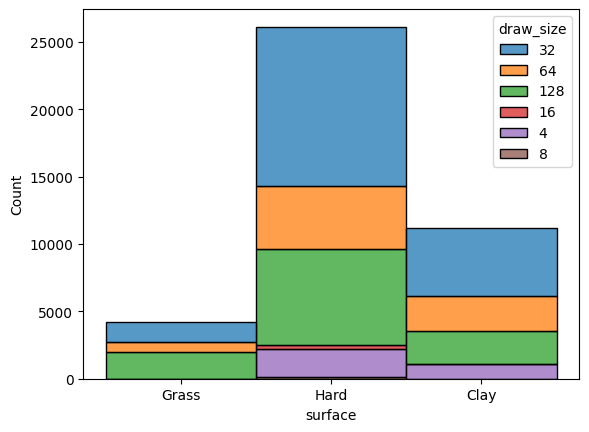

In [ ]:
sns.histplot(
    active_df,
    x="surface",
    hue="draw_size",
    multiple="stack"
)

<Axes: xlabel='minutes', ylabel='total_gemes'>

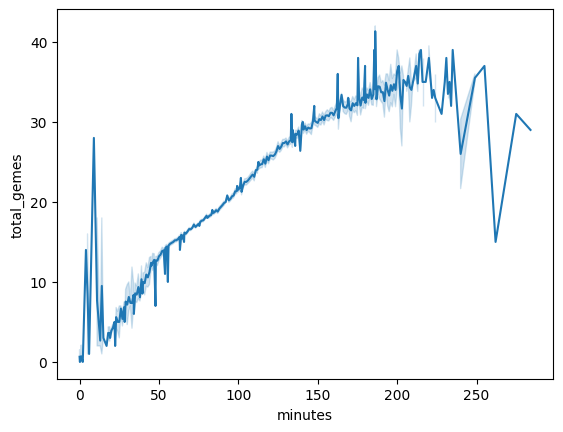

In [ ]:
sns.lineplot(
    active_df,
    x='minutes',
    y='total_gemes'
)

### SAVE DATA

In [ ]:
# save data
matches_cleaned.to_csv('/Users/martapriv/Documents/PUM/inzynierka_code/Tennis_Scores_Predictions/data/02_intermediate/matches_cleaned.csv')